# Proton model prerequisite — Geant4 proton calibration pilot

## Scientific question

Before choosing any stochastic family for proton FastMC events, **measure what a proton
actually looks like in this unusually thin calorimeter**: 17 $X_0$ but only about
0.6 $\lambda_I$ deep. The literature pass of 2026-09-28 could not settle this regime; every
surviving counterargument pointed to the same instrument - a simulation of protons in this
exact geometry.

This notebook calls tested code only (`ams_ecal.geant4_backend`, `ams_ecal.pilot_analysis`,
`ams_ecal.pilot_report`). The numbers come from `results/geant4_proton_pilot/summary.json`,
produced by `uv run python -m ams_ecal.pilot_report` from committed configuration.

**Geant4 is a model, not detector truth.** Every statement below is about Geant4 11.4.1
with FTFP_BERT (QBBC as a small systematic check) in our implemented material model.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

from ams_ecal.geant4_backend import load_batch
from ams_ecal.geometry import load_geometry
from ams_ecal.transport_geometry import load_transport_config, prefix_mesh

ROOT = Path.cwd().parent
RESULTS = ROOT / "results" / "geant4_proton_pilot"
DATA = ROOT / "data" / "geant4_proton_pilot"
summary = json.loads((RESULTS / "summary.json").read_text(encoding="utf-8"))
geometry = load_geometry(ROOT / "configs" / "geometry.yaml")
audit = json.loads((RESULTS / "geometry_audit.json").read_text(encoding="utf-8"))
energies = sorted(summary["interaction"], key=float)
print("energies [GeV]:", energies)
print("provenance (baseline):", {e: v["git"]["commit"][:8] + (" dirty" if v["git"]["tracked_changes"] else " clean")
                                  for e, v in summary["provenance"]["baseline"].items()})

energies [GeV]: ['10', '20', '50', '100']
provenance (baseline): {'100': '00d70fdc clean', '10': '00d70fdc clean', '20': '00d70fdc clean', '50': '00d70fdc clean'}


## 1. Why a proton is not a small electron shower

**Established fact.** Bremsstrahlung scales as $1/m^2$: a proton radiates
$(m_e/m_p)^2 \approx 3\times10^{-7}$ as strongly as an electron, so it crosses the ECAL
ionizing like a minimum-ionizing particle (MIP) *until it hits a nucleus*
(PDG RPP 2024 §34.6).

**Established fact.** The nuclear collision happens on the scale of the nuclear interaction
length $\lambda_I$, which in lead is about 30 times longer than $X_0$. The AMS ECAL is
"17 radiation lengths (0.6 nuclear interaction lengths)" deep (Vecchi et al., SF2A 2012,
arXiv:1210.0316, §2) - **AMS-specific evidence**.

So an electron shower is essentially complete inside the ECAL, while a proton is observed,
at best, **at the start** of its cascade.

In [2]:
print("Our implemented material model (Geant4-derived, not tuned to round numbers):")
for key in ("radiation_length_mm", "nuclear_interaction_length_mm", "depth_x0", "depth_lambda_i",
            "effective_density_g_cm3", "total_mass_kg"):
    print(f"  {key:32s} {audit[key]:.4g}")
print("  overlaps found:", audit["overlap_check"]["volumes_with_overlaps"] or "none",
      "| volumes checked:", audit["overlap_check"]["volumes_checked"])

Our implemented material model (Geant4-derived, not tuned to round numbers):
  radiation_length_mm              9.979
  nuclear_interaction_length_mm    269.3
  depth_x0                         16.68
  depth_lambda_i                   0.6182
  effective_density_g_cm3          6.8
  total_mass_kg                    475.4
  overlaps found: none | volumes checked: {'ECAL': 1, 'Fibre_x': 4795, 'Fibre_y': 4795, 'Superlayer': 9}


## 2. The meaning of 0.6 $\lambda_I$: an exponential law

If the probability of an inelastic collision per unit depth is constant, $1/\lambda$, the
probability $P(z)$ of reaching depth $z$ without one obeys

$$
\frac{dP}{dz} = -\frac{P}{\lambda}
\quad\Longrightarrow\quad
P(z) = e^{-z/\lambda},
\qquad P(\text{no inelastic in } L) = e^{-L/\lambda}.
$$

With $L = 0.6\,\lambda$: $e^{-0.6} = 0.549$. **Derived**, and only as good as its two inputs:
the constant rate (a *model assumption* of this derivation) and the value of $\lambda$ for
protons at this energy. The pilot measures both: the depth distribution tests the constant
rate, and a censored-exponential fit gives the effective $\lambda$ for each energy.

Censoring matters: protons that cross the slab contribute exposure $L$ but no depth, so the
maximum-likelihood rate is $\hat\mu = n_\text{int} / (\sum_i D_i + n_\text{cross} L)$.

In [3]:
print(f"{'E [GeV]':>7s} {'P(no inel.)':>12s} {'95% CI':>17s} {'fit':>6s} {'lambda_eff [mm]':>16s} {'L/lambda':>9s} {'KS p':>6s}")
for e in energies:
    s = summary["interaction"][e]
    p, lam = s["p_no_inelastic"], s["effective_interaction_length_mm"]
    print(f"{e:>7s} {p['estimate']:12.3f}   [{p['low']:.3f}, {p['high']:.3f}] {s['p_no_inelastic_from_fit']:6.3f}"
          f" {lam['estimate']:9.1f} +- {lam['standard_error']:4.1f} {s['effective_depth_lambda']:9.3f}"
          f" {s['depth_ks_vs_exponential']['p_value']:6.2f}")
print(f"\nexp(-0.6) = {np.exp(-0.6):.3f}")

E [GeV]  P(no inel.)            95% CI    fit  lambda_eff [mm]  L/lambda   KS p
     10        0.530   [0.515, 0.545]  0.529     261.8 +-  6.0     0.636   0.91
     20        0.512   [0.496, 0.527]  0.512     248.8 +-  5.6     0.669   0.76
     50        0.516   [0.501, 0.532]  0.516     251.3 +-  5.7     0.663   0.68
    100        0.526   [0.511, 0.542]  0.527     260.3 +-  6.0     0.640   0.25

exp(-0.6) = 0.549


**What the table shows.** Between 51% and 53% of protons cross the ECAL without an inelastic interaction at every energy from 10 to 100 GeV - 2 to 4 percentage points below $e^{-0.6} = 0.549$. The fitted effective interaction length is 249-262 mm, so for protons the prefix is **0.64-0.67 $\lambda$** deep, slightly more than the nominal 0.6 (and close to the 0.618 Geant4 computes for the composite from its geometric formula). No energy trend is resolved over 10-100 GeV. The depth distribution is consistent with a pure exponential at every energy (KS p = 0.25-0.91), so the constant-rate assumption survives this test.

**Interpretation.** A single effective interaction length is an adequate FastMC parameter over this range. *Provenance: project simulation evidence (Geant4 11.4.1, FTFP_BERT), not AMS data.*

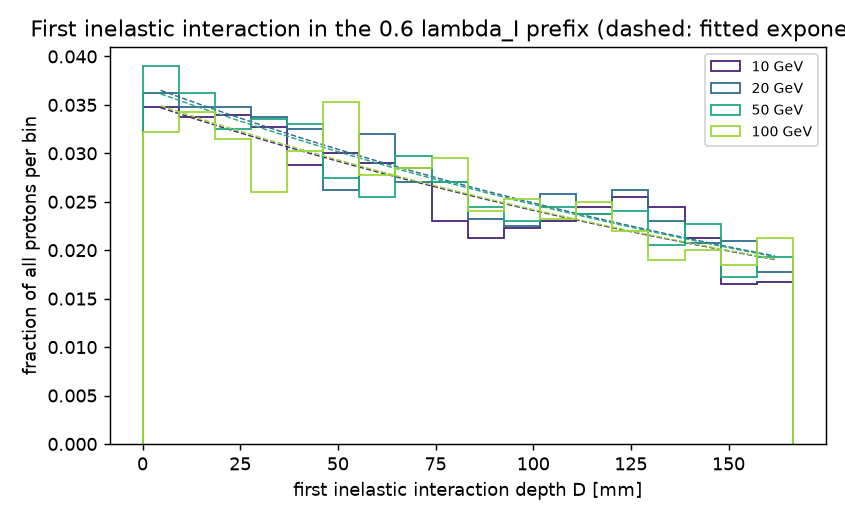

In [4]:
display(Image(filename=str(RESULTS / "fig1_interaction_depth.png")))

## 3. Inelastic does not mean visibly showering

The exponential counts **inelastic** collisions - a *truth-level* statement. The ECAL only sees
scintillator light. An inelastic collision can be quasi-elastic (one leading hadron keeps most
of the energy), low-multiplicity, or so late that little of the cascade lies inside. So the
**detector-level** population that looks MIP-like need not equal the truth-level
non-interacting population. The pilot measures both, separately.

How truth is decided here (**operational definition**, tested): the first step of the primary
proton whose Geant4 post-step *defining process* is hadronic and named `*Inelastic`.
Ionisation, multiple scattering, transport and `hadElastic` never count. An independent finder
based on the primary's secondaries is kept as a cross-check, and the two agree exactly on
occurrence and depth.

The MIP scale is **measured**, from truth-non-interacting events, not taken from an
order-of-magnitude estimate. The "MIP band" is an **analysis choice**: the 99% upper quantile of
non-interacting events' scintillator energy (95% and 99.9% as variations).

In [5]:
d = summary["detector"]
print("measured MIP scale:", {k: round(v, 3) for k, v in d["mip_scale_mev"].items()}, "MeV (scintillator)")
for e in energies:
    s = d[e]
    ni, band = s["non_interacting"], s["mip_band"]["0.99"]
    print(f"\n{e} GeV  non-interacting: scintillator {ni['energy_mev_mean_sd'][0]:.1f} +- {ni['energy_mev_mean_sd'][1]:.1f} MeV,"
          f" all-material {ni['deposit_total_mev_mean']:.0f} MeV, scint/total {ni['scintillator_over_total']:.3f},"
          f" layer CV {ni['layer_to_layer_cv']:.2f}")
    print(f"        detector MIP-like (all events)      {band['fraction_all_events_mip_like']['estimate']:.3f}")
    print(f"        truth-inelastic but MIP-like        {band['fraction_interacting_mip_like']['estimate']:.3f}"
          f"  [{band['fraction_interacting_mip_like']['low']:.3f}, {band['fraction_interacting_mip_like']['high']:.3f}]")
    q = summary["interaction"][e]
    print(f"        quasi-elastic-like (leading > 90%)  {q['quasi_elastic_like_fraction']:.3f}")

measured MIP scale: {'cell': 0.56, 'layer': 0.569} MeV (scintillator)

10 GeV  non-interacting: scintillator 11.4 +- 1.8 MeV, all-material 154 MeV, scint/total 0.074, layer CV 0.45
        detector MIP-like (all events)      0.531
        truth-inelastic but MIP-like        0.014  [0.009, 0.020]
        quasi-elastic-like (leading > 90%)  0.099

20 GeV  non-interacting: scintillator 11.9 +- 2.8 MeV, all-material 166 MeV, scint/total 0.072, layer CV 0.47
        detector MIP-like (all events)      0.519
        truth-inelastic but MIP-like        0.025  [0.019, 0.033]
        quasi-elastic-like (leading > 90%)  0.092

50 GeV  non-interacting: scintillator 12.5 +- 4.6 MeV, all-material 177 MeV, scint/total 0.071, layer CV 0.47
        detector MIP-like (all events)      0.519
        truth-inelastic but MIP-like        0.017  [0.012, 0.023]
        quasi-elastic-like (leading > 90%)  0.073

100 GeV  non-interacting: scintillator 13.1 +- 6.9 MeV, all-material 189 MeV, scint/total 0.070, l

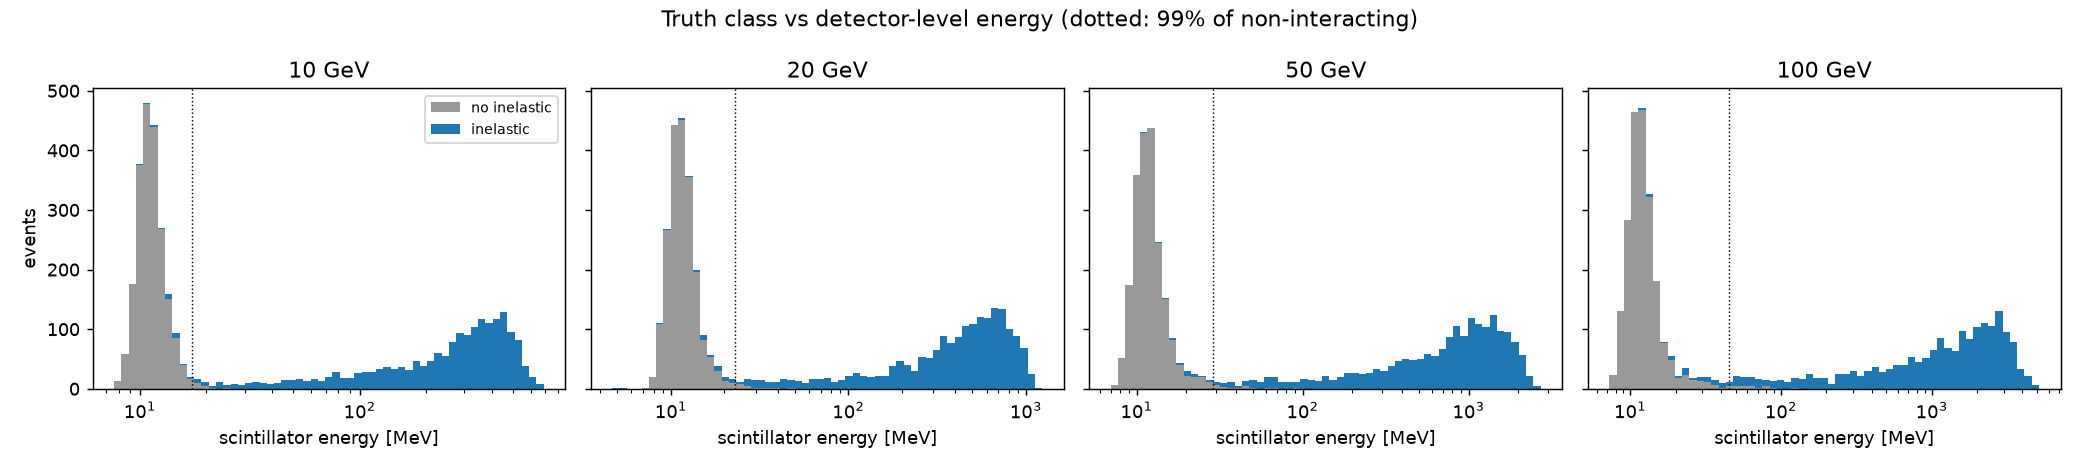

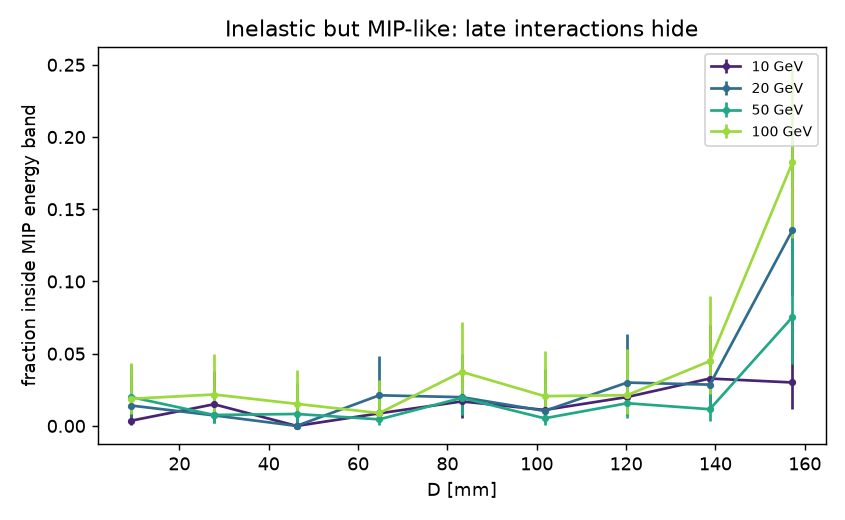

In [6]:
display(Image(filename=str(RESULTS / "fig2_visible_energy_by_truth.png")))
display(Image(filename=str(RESULTS / "fig4_mip_like_vs_depth.png")))

**What the numbers show.** A crossing proton leaves 11.4-13.1 MeV of scintillator energy (0.56 MeV in the crossed cell of one layer; 7.4% of its ~150-190 MeV total deposit). Its spread grows with energy (standard deviation 1.8 MeV at 10 GeV, 6.9 MeV at 100 GeV), and one layer fluctuates by about 47% around its mean.

**Truth class vs detector class nearly coincide.** The detector-level MIP-like fraction agrees with the truth-level non-interacting fraction within about one percentage point at every energy. Only 1.4-3.6% of inelastic events fall inside the MIP band (0.6-1.1% with the 95% band, 2.3-7.5% with the 99.9% band), and they concentrate in the last ~2 cm, where 3-18% of interactions look MIP-like. About 7-10% of first interactions are quasi-elastic-like (leading particle above 90% of the energy), yet almost none of them stay MIP-like: their products still light the fibres.

**Interpretation.** For this geometry, *inelastic but invisible* is a small population that arises naturally from late interactions; it does not require a separate detector-level class.

## 4. Why truncation matters

For thick hadron calorimeters the depth of the **cascade maximum** is
$t_\text{max} \approx 0.2\ln(E/\text{GeV}) + 0.7$ in units of $\lambda$
(Leroy & Rancoita, p. 562, text under Eq. 93 - verified on 2026-09-28). This is a cascade
*maximum*, not a containment depth. At 10 GeV it is 1.16 $\lambda$, at 100 GeV 1.62 $\lambda$:
the average hadronic maximum lies *beyond* the 0.6 $\lambda_I$ ECAL. AMS sees the beginning.

Whole-shower parameterisations therefore cannot be transferred as they stand. The pilot adds
a **research instrument**: 126 more AMS-like superlayers behind the ECAL, so the *same event*
can be read through the 18-layer prefix and through the full 270 layers, in the same
scintillator representation.

In [7]:
for e in (10, 100):
    print(f"t_max({e} GeV) = {0.2 * np.log(e) + 0.7:.2f} lambda  vs  ECAL depth ~0.6-0.64 lambda")

t_max(10 GeV) = 1.16 lambda  vs  ECAL depth ~0.6-0.64 lambda
t_max(100 GeV) = 1.62 lambda  vs  ECAL depth ~0.6-0.64 lambda


## 5. What the Geant4 backend records

* `readout_grid_mev` - **the detector image**: energy deposited in the 43 155 scintillating
  fibres, projected to the canonical 18 x 72 readout. Not calibrated, not digitized.
* `deposit_grid_mev` - **truth accounting only**: energy in all material.
* `edep_scintillator + edep_matrix = edep_total`, from independent scorers (closes to 1e-9).
* fine deposits: every fibre, and 3 x 3 x 4.625 mm voxels - kept for RQ-001.
* first-interaction truth: position, depth in mm / $X_0$ / $\lambda_I$, energy before, material,
  and every product (PDG code, kinetic energy).

Below: one crossing proton and one interacting proton at 100 GeV, as fine voxels (truth) and
as the 18 x 72 readout (detector image).

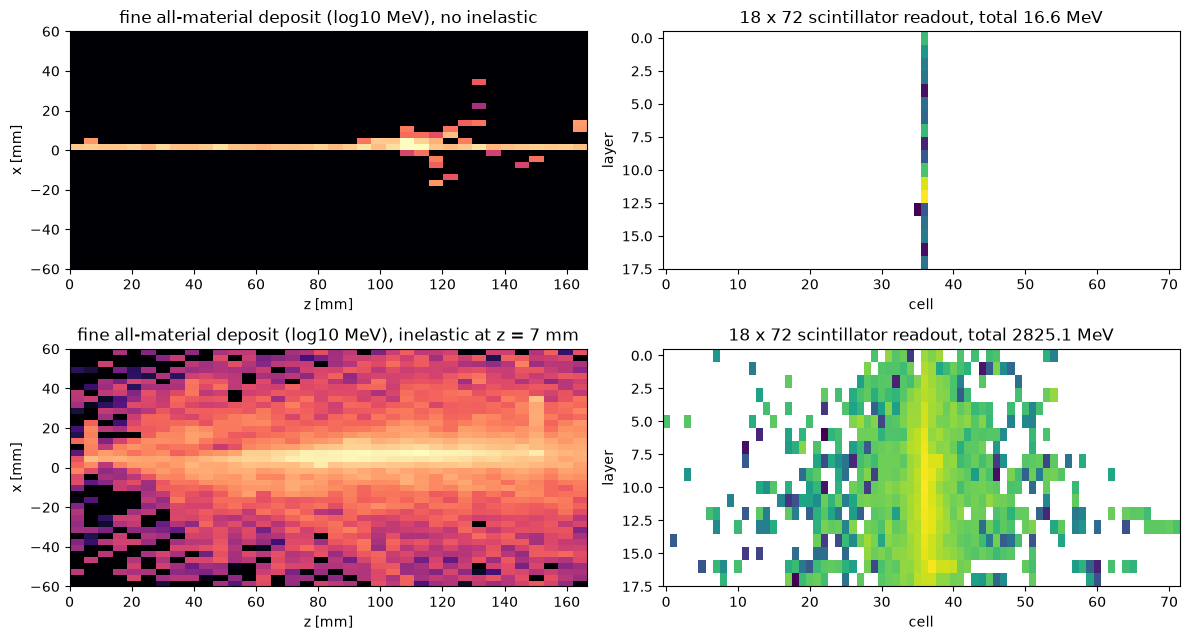

In [8]:
batch = load_batch(DATA / "baseline" / "E100GeV")
a = batch.arrays
grid_spec = prefix_mesh(geometry, load_transport_config(ROOT / "configs" / "geant4_transport.yaml"))
crossing = int(np.flatnonzero(~a["truth_occurred"])[0])
interacting = int(np.flatnonzero(a["truth_occurred"] & (a["truth_z_mm"] < 60))[0])

fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))
for row, i in enumerate((crossing, interacting)):
    index, edep = batch.fine_deposits(i)
    x, y, z = grid_spec.centres_mm(index)
    image, xe, ze = np.histogram2d(x, z, bins=[np.arange(-60, 63, 3.0), np.arange(0, 171.125, 4.625)], weights=edep)
    axes[row, 0].pcolormesh(ze, xe, np.log10(image + 1e-3), cmap="magma")
    axes[row, 0].set_xlabel("z [mm]"); axes[row, 0].set_ylabel("x [mm]")
    title = "no inelastic" if row == 0 else f"inelastic at z = {a['truth_z_mm'][i]:.0f} mm"
    axes[row, 0].set_title(f"fine all-material deposit (log10 MeV), {title}")
    axes[row, 1].imshow(a["readout_grid_mev"][i], aspect="auto", cmap="viridis", norm="log")
    axes[row, 1].set_xlabel("cell"); axes[row, 1].set_ylabel("layer")
    axes[row, 1].set_title(f"18 x 72 scintillator readout, total {a['edep_scintillator_mev'][i]:.1f} MeV")
fig.tight_layout(); plt.show()

## 6. Observables against the first-interaction depth

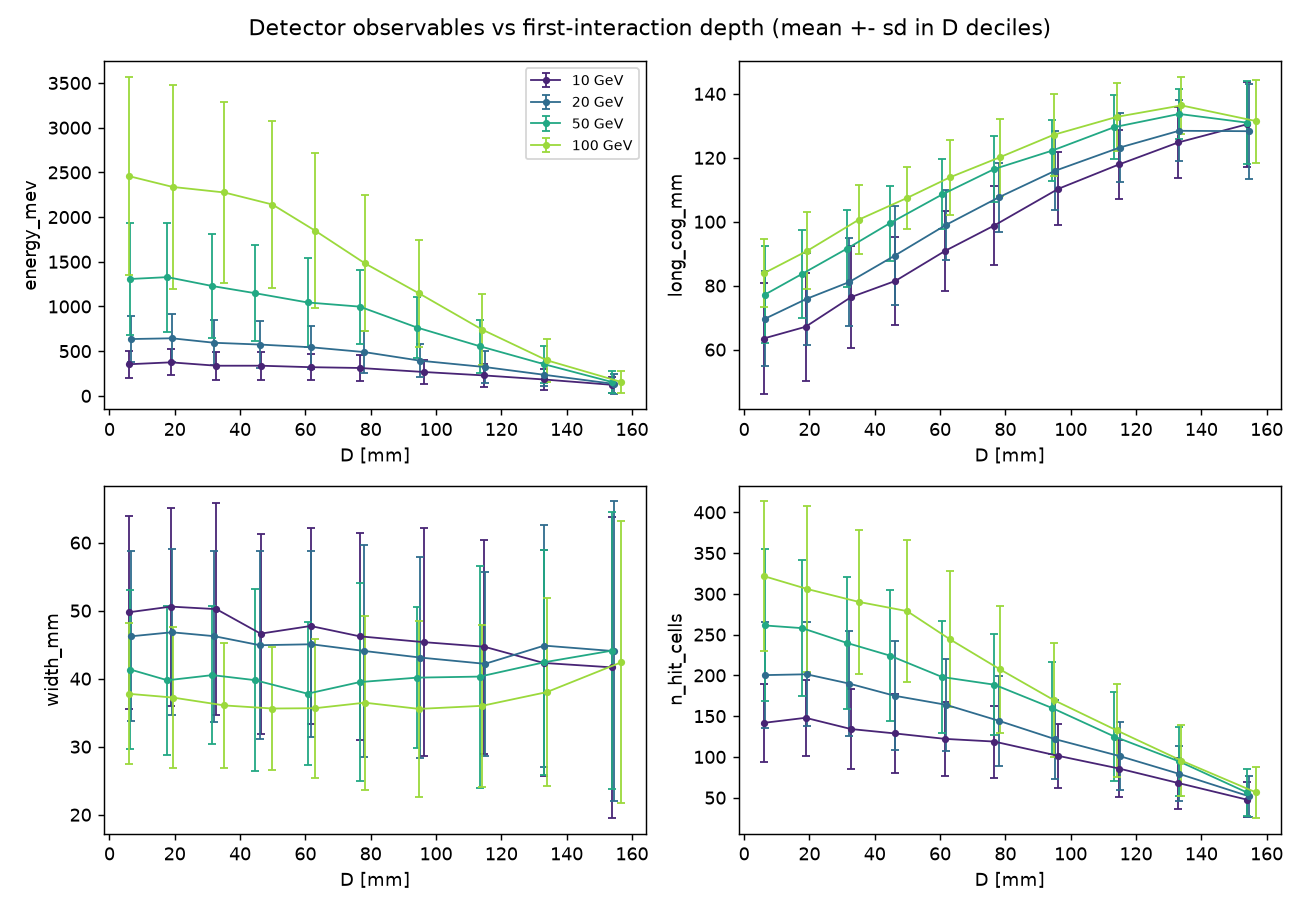

In [9]:
display(Image(filename=str(RESULTS / "fig3_observables_vs_depth.png")))

## 7. Depth-dominance hypothesis — does the first-interaction depth dominate?

**Hypothesis the depth-dominance hypothesis (unproven).** *First-interaction depth dominates proton event-to-event
variation.* Test it with the law of total variance. For an observable $Y$ and depth $D$,

$$
\operatorname{Var}(Y) = \operatorname{Var}\!\big(\mathbb E[Y\mid D]\big) + \mathbb E\!\big[\operatorname{Var}(Y\mid D)\big],
\qquad
S_D = \frac{\operatorname{Var}(\mathbb E[Y\mid D])}{\operatorname{Var}(Y)} .
$$

$\mathbb E[Y\mid D]$ is estimated as the mean of $Y$ in 10 equal-count bins of $D$. The raw
between-bin share ($\eta^2$) is biased upward by bin noise, by about $(K-1)/N\,(1-S_D)$; the
table reports the bias-adjusted $\varepsilon^2$ with a 95% bootstrap interval, and the
sensitivity to 5 and 20 bins.

$S_D$ is the share of variance **statistically associated** with $D$ under this binning - not
a causal Sobol index, because $D$ is not set by us.

observable                        10 GeV                20 GeV                50 GeV               100 GeV
energy_mev           0.24 [0.21,0.27]   0.37 [0.34,0.41]   0.42 [0.40,0.46]   0.50 [0.47,0.53]
log_energy           0.19 [0.16,0.23]   0.30 [0.27,0.36]   0.42 [0.37,0.48]   0.49 [0.44,0.54]
long_cog_mm          0.73 [0.71,0.76]   0.72 [0.70,0.75]   0.74 [0.71,0.76]   0.70 [0.67,0.74]
long_rms_mm          0.33 [0.29,0.37]   0.37 [0.33,0.43]   0.42 [0.39,0.46]   0.48 [0.44,0.51]
width_mm             0.03 [0.02,0.05]   0.00 [0.00,0.02]   0.01 [0.00,0.03]   0.02 [0.01,0.05]
n_hit_cells          0.36 [0.33,0.39]   0.46 [0.43,0.50]   0.49 [0.46,0.53]   0.57 [0.54,0.61]
n_active_layers      -0.00 [-0.00,0.01]   -0.00 [-0.00,0.01]   -0.00 [-0.00,0.01]   0.01 [0.00,0.03]


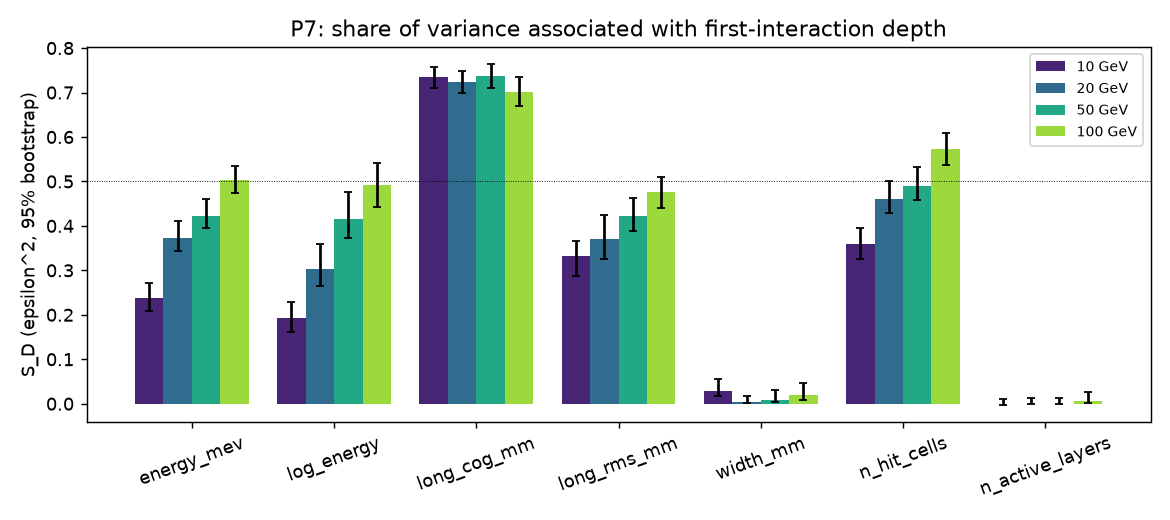

In [10]:
names = list(summary["p7"][energies[0]]["observables"])
print(f"{'observable':18s}" + "".join(f"{e + ' GeV':>22s}" for e in energies))
for name in names:
    line = f"{name:18s}"
    for e in energies:
        s = summary["p7"][e]["observables"][name]["s_d_epsilon_squared"]
        line += f"   {s['estimate']:.2f} [{s['low']:.2f},{s['high']:.2f}]"
    print(line)
display(Image(filename=str(RESULTS / "fig5_p7_variance_fraction.png")))

**Depth-dominance hypothesis is partly supported, and only for some observables.** $D$ is associated with about 0.70-0.74 of the variance of the longitudinal centre at every energy - it dominates *where* the energy is. For hit multiplicity (0.36-0.57), visible energy (0.24-0.50) and longitudinal RMS (0.33-0.48) it is a large but minority share that grows with energy. For transverse width it explains essentially nothing (0.00-0.03). The binning variations (5, 10, 20 bins) move these by at most a few hundredths. Active-layer count is uninformative at a half-MIP threshold, because every proton lights all 18 layers.

**Interpretation.** $D$ is a necessary latent variable for a proton model of this ECAL, but not a sufficient one. At least one more latent is needed for how much energy becomes visible, and the lateral spread needs its own.

## 8. Thin prefix vs extended calorimeter — the same events

Correlations transferred from deep calorimeters assume the whole shower is seen. Here, for
events whose first inelastic interaction lies inside the prefix, the same event is read through
the 18 prefix layers and through all 270 layers.


10 GeV  (n interacting in prefix = 391)
  r_s(D, energy_mev   ) thin -0.44  full +0.18  diff -0.62 [-0.74,-0.47]   S_D thin 0.20 full 0.06
  r_s(D, long_cog_mm  ) thin +0.87  full +0.31  diff +0.57 [+0.48,+0.66]   S_D thin 0.74 full 0.04
  r_s(D, long_rms_mm  ) thin -0.36  full -0.04  diff -0.32 [-0.46,-0.17]   S_D thin 0.37 full -0.00
  r_s(D, width_mm     ) thin +0.10  full +0.08  diff +0.03 [-0.09,+0.14]   S_D thin 0.01 full -0.00
  r_s(D, n_hit_cells  ) thin -0.54  full +0.20  diff -0.74 [-0.87,-0.58]   S_D thin 0.28 full 0.05
  energy rank agreement thin vs full: -0.20 [-0.29,-0.10]
  backsplash: mean prefix energy (no prefix interaction) extended 26.52 vs AMS-only 11.38 MeV, KS p = 1.3e-95

20 GeV  (n interacting in prefix = 363)
  r_s(D, energy_mev   ) thin -0.62  full +0.28  diff -0.91 [-1.05,-0.76]   S_D thin 0.41 full 0.08
  r_s(D, long_cog_mm  ) thin +0.86  full +0.44  diff +0.42 [+0.32,+0.51]   S_D thin 0.73 full 0.09
  r_s(D, long_rms_mm  ) thin -0.38  full +0.08  diff -0

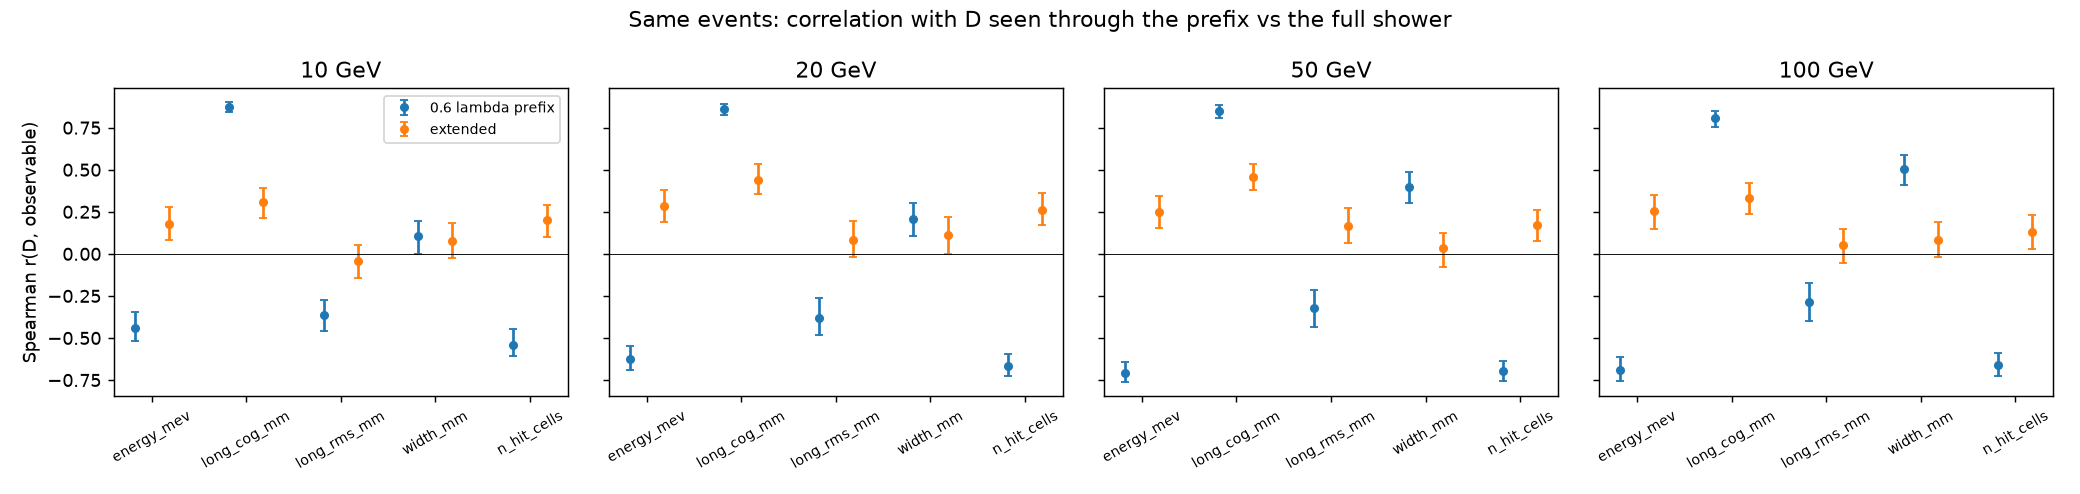

In [11]:
if "truncation" in summary:
    for e, entry in sorted(summary["truncation"].items(), key=lambda kv: float(kv[0])):
        print(f"\n{e} GeV  (n interacting in prefix = {entry['n_interacting_in_prefix']})")
        for name, c in entry["depth_correlations"].items():
            t, f, dlt = c["spearman_thin"], c["spearman_full"], c["thin_minus_full"]
            print(f"  r_s(D, {name:13s}) thin {t['estimate']:+.2f}  full {f['estimate']:+.2f}"
                  f"  diff {dlt['estimate']:+.2f} [{dlt['low']:+.2f},{dlt['high']:+.2f}]"
                  f"   S_D thin {c['s_d_thin']:.2f} full {c['s_d_full']:.2f}")
        r = entry["energy_rank_agreement_thin_vs_full"]
        print(f"  energy rank agreement thin vs full: {r['estimate']:.2f} [{r['low']:.2f},{r['high']:.2f}]")
        if "backsplash" in entry:
            b = entry["backsplash"]
            print(f"  backsplash: mean prefix energy (no prefix interaction) extended {b['mean_prefix_energy_extended_mev']:.2f}"
                  f" vs AMS-only {b['mean_prefix_energy_ams_only_mev']:.2f} MeV, KS p = {b['ks_p_value']:.2g}")
    display(Image(filename=str(RESULTS / "fig6_truncation_correlations.png")))

**The correlation structure of a deep calorimeter does not transfer.** For the *same* events, $r(D, E)$ is -0.44 to -0.71 in the prefix but +0.18 to +0.28 in the full shower; hit multiplicity flips the same way; the longitudinal centre drops from about +0.85 to +0.3-0.46. In the full shower, $D$ explains under 15% of any observable; in the prefix it is the leading variable for position and energy. Ranking events by prefix energy is *anti*-correlated with their full-shower energy ($\rho$ = -0.20 to -0.37).

**Backsplash caveat.** Material behind the ECAL sends energy back into it: protons that do not interact in the prefix show 26-45 MeV there instead of 11-13 MeV, and 34-47% exceed the MIP band. For prefix-interacting events the energy and longitudinal conclusions match the AMS-only baseline (S_D 0.49 vs 0.50 for energy at 100 GeV), but prefix *width* becomes D-dependent only in the extended geometry - a backsplash artefact. Width conclusions therefore come from the AMS-only sample.

**Interpretation.** What AMS sees of a proton is shaped by truncation more than by the shower's own correlations. Whatever sits behind the real AMS ECAL may matter; this is an open question.

## 9. Controls: physics list and entry point


=== physics_list ===
   10 GeV  P(no inel.) 0.530 vs 0.517 | lambda_eff 262 vs 254 mm | median E_int 292 vs 304 MeV | S_D(E) 0.24 vs 0.28 | KS(E_int) p=0.62 | crossing var ratio 0.94
   20 GeV  P(no inel.) 0.512 vs 0.514 | lambda_eff 249 vs 253 mm | median E_int 450 vs 436 MeV | S_D(E) 0.37 vs 0.29 | KS(E_int) p=0.63 | crossing var ratio 0.77
   50 GeV  P(no inel.) 0.516 vs 0.515 | lambda_eff 251 vs 250 mm | median E_int 833 vs 898 MeV | S_D(E) 0.42 vs 0.49 | KS(E_int) p=0.063 | crossing var ratio 1.52
  100 GeV  P(no inel.) 0.526 vs 0.524 | lambda_eff 260 vs 259 mm | median E_int 1329 vs 1319 MeV | S_D(E) 0.50 vs 0.49 | KS(E_int) p=0.31 | crossing var ratio 2.38

=== fixed_entry ===
   10 GeV  P(no inel.) 0.530 vs 0.529 | lambda_eff 262 vs 261 mm | median E_int 292 vs 293 MeV | S_D(E) 0.24 vs 0.30 | KS(E_int) p=0.89 | crossing var ratio 1.15
   20 GeV  P(no inel.) 0.512 vs 0.520 | lambda_eff 249 vs 258 mm | median E_int 450 vs 428 MeV | S_D(E) 0.37 vs 0.35 | KS(E_int) p=0.16 | crossi

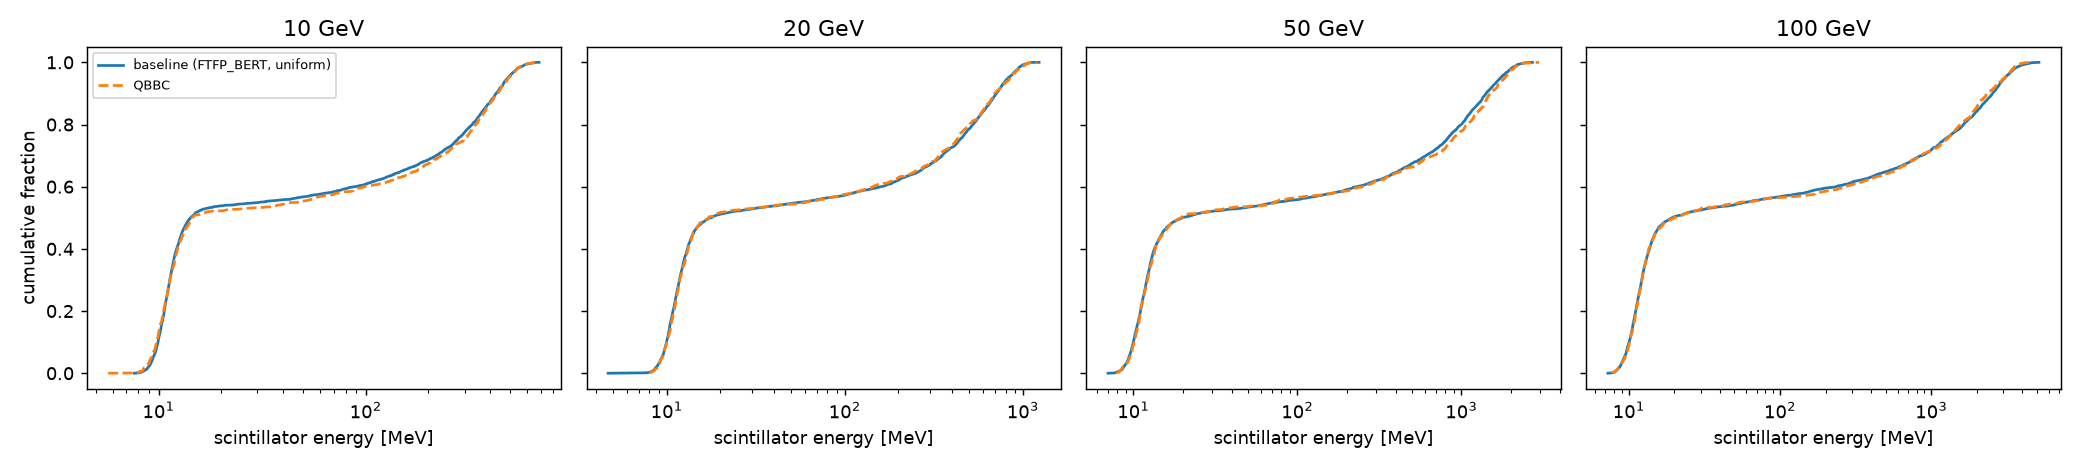

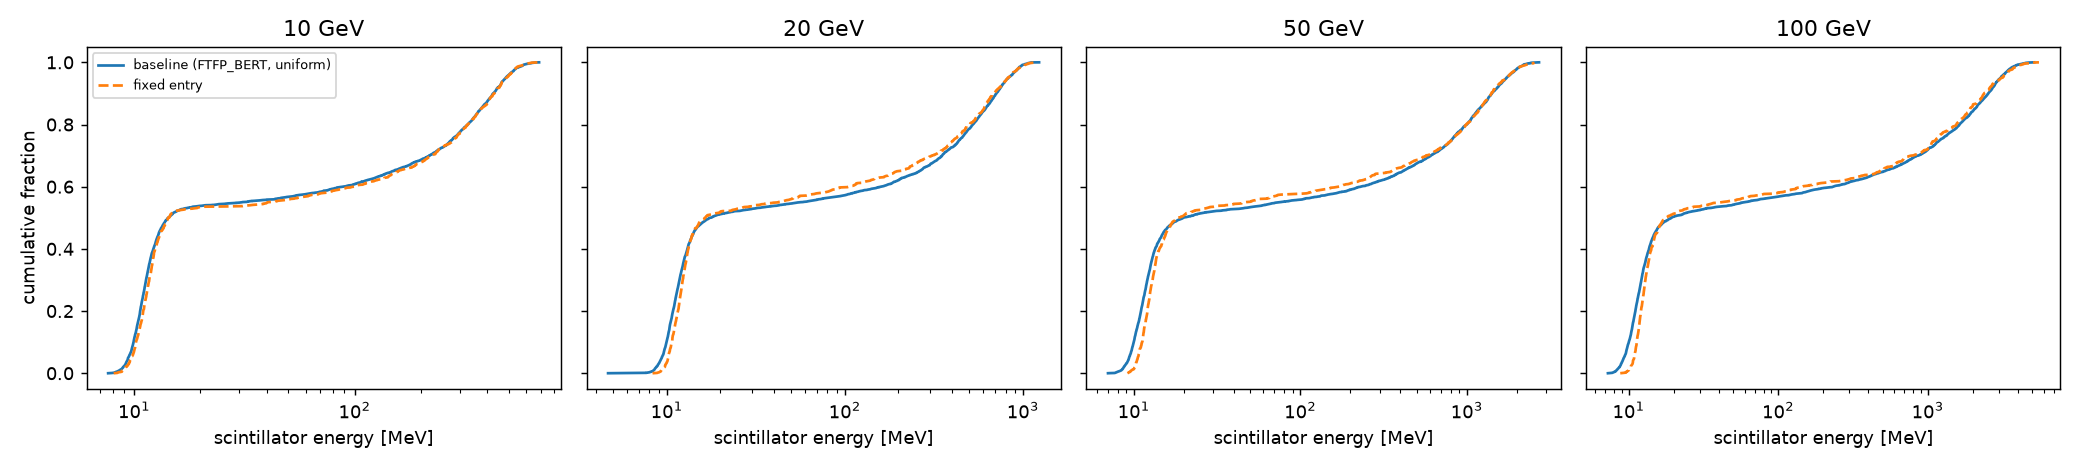

In [12]:
for section, label in (("physics_list", "alternate"), ("fixed_entry", "fixed_entry")):
    if section not in summary:
        continue
    print(f"\n=== {section} ===")
    for e, entry in sorted(summary[section].items(), key=lambda kv: float(kv[0])):
        b, o = entry["baseline"], entry[label]
        print(f"{e:>5s} GeV  P(no inel.) {b['p_no_inelastic']['estimate']:.3f} vs {o['p_no_inelastic']['estimate']:.3f}"
              f" | lambda_eff {b['effective_interaction_length_mm']:.0f} vs {o['effective_interaction_length_mm']:.0f} mm"
              f" | median E_int {b['interacting_energy_quantiles_mev'][1]:.0f} vs {o['interacting_energy_quantiles_mev'][1]:.0f} MeV"
              f" | S_D(E) {b['s_d_energy']:.2f} vs {o['s_d_energy']:.2f}"
              f" | KS(E_int) p={entry['ks_interacting_energy']['p_value']:.2g}"
              f" | crossing var ratio {entry['crossing_energy_variance_ratio']['estimate']:.2f}")
for name in ("fig7_physics_list.png", "fig8_fixed_entry.png"):
    if (RESULTS / name).exists():
        display(Image(filename=str(RESULTS / name)))

**Hadronic model.** QBBC agrees with FTFP_BERT everywhere - but Geant4's model table shows both use FTFP for protons above 3 GeV, so that check varies cross-sections and secondary cascades, not the first interaction. QGSP_BERT (QGS above 12 GeV, same cross-sections) was therefore added. It agrees on interaction probability, depth distribution, crossing protons and the qualitative the depth-dominance hypothesis pattern, and is identical at 10 GeV where it too uses FTFP/Bertini. But at 20-100 GeV it gives **lower visible energy** (medians 343/601/1162 vs 450/833/1329 MeV) and narrower showers (KS p = 1e-6 at 20 and 50 GeV). **Structure is robust; the visible-energy scale carries a hadronic-model systematic of order 10-30%.**

**Entry point.** Fixing the entry at the cell centre leaves interacting events unchanged but shifts the crossing-proton signal significantly (e.g. 14.5 vs 13.1 MeV at 100 GeV; KS p down to 1e-25). The phase of the track relative to the 1 mm fibre lattice is a real component of the MIP-level signal - exactly what the uniform spot averages over.

## 10. What this implies for the proton model

The model decision belongs to the researcher. The proposal derived from these distributions is
written in `research/STATE.md` and the Obsidian evidence record; it is **not** implemented.

### Proposed structure for the researcher's decision (not implemented)

1. **Branch:** $I \sim \text{Bernoulli}$, $P(\text{no inelastic}) = e^{-L/\lambda_\text{eff}}$ with one $\lambda_\text{eff} \approx 255$ mm.
2. **Depth:** $D \mid I \sim$ exponential($\lambda_\text{eff}$) truncated to the ECAL.
3. **Track:** every layer before $D$ (all 18 if $I = 0$) receives an independent per-layer scintillator deposit from the measured crossing-proton distribution (median 0.56 MeV, adjacent layers nearly uncorrelated, $\rho \approx$ 0.1-0.18), in the crossed cell.
4. **Interaction at $D$:**
   - visible energy from the remaining depth and $E$: $\log E_\text{vis} = \mu(E, L - D) + \varepsilon$, where $\varepsilon$ has a heavy low tail and - exploratory - nearly the **same shape at all four energies**;
   - longitudinal shape starting at $D$, with its own residual latent;
   - hit multiplicity **follows** visible energy ($\rho \approx$ 0.8-0.9), not a separate latent;
   - lateral width with its own latent, nearly independent of $D$.

**Not justified by the data:** a fixed visible fraction; a flat individual profile; a whole-shower profile truncated afterwards; a correlation matrix transferred from deep calorimeters; a separate low-visible class. **Open:** tabulated (empirical-quantile) versus parametric families for $\varepsilon$ and the shapes; how to carry the FTFP_BERT vs QGSP_BERT energy-scale systematic; backsplash from material behind the real ECAL; incidence angles (only normal incidence studied).